In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional


def plot_ct3_heatmap(
    csv_path: str | Path,
    *,
    experiment_id: Optional[int] = None,
    value_col: str = "ct3_abs_mean",
    title: str | None = None,
    cmap: str = "viridis",
    figsize=(6, 5),
    annotate: bool = False,
    annotation_fmt: str = ".3g",
) -> None:
    """
    Plot a CT3 heatmap from the aggregated-across-seeds CSV.

    Expected columns include:
      - experiment_id (optional but typical)
      - <theta>, <theta>_prime    (e.g., mu, mu_prime or phi, phi_prime)
      - ct3_signed_mean, ct3_signed_std, ct3_abs_mean, ct3_abs_std, n_seeds, ...

    Parameters
    ----------
    csv_path : str | Path
        Path to CSV.
    experiment_id : int | None
        If provided, filter to this experiment_id. If None and the CSV has multiple
        experiment_ids, the function will raise with a helpful message.
    value_col : str
        Which column to visualize, e.g. "ct3_abs_mean", "ct3_abs_std",
        "ct3_signed_mean", "ct3_signed_std".
    annotate : bool
        If True, write numeric values into each cell.
    """
    df = pd.read_csv(csv_path)

    # ---- handle experiment_id filtering ----
    if "experiment_id" in df.columns:
        exp_ids = sorted(df["experiment_id"].dropna().unique().tolist())
        if experiment_id is None:
            if len(exp_ids) != 1:
                raise ValueError(
                    f"CSV contains multiple experiment_id values {exp_ids}. "
                    "Pass experiment_id=... to select one."
                )
            experiment_id = int(exp_ids[0])

        df = df[df["experiment_id"] == experiment_id].copy()
        if df.empty:
            raise ValueError(f"No rows found for experiment_id={experiment_id} in {csv_path}")

    # ---- infer theta + theta_prime columns ----
    prime_cols = [c for c in df.columns if c.endswith("_prime")]
    if len(prime_cols) == 0:
        raise ValueError(f"No '*_prime' column found in CSV: {list(df.columns)}")
    if len(prime_cols) > 1:
        # If you ever store multiple theta dimensions, this needs explicit args.
        raise ValueError(f"Multiple '*_prime' columns found: {prime_cols}. Specify a simpler CSV.")

    theta_prime = prime_cols[0]
    theta = theta_prime[:-6]  # remove "_prime"

    if theta not in df.columns:
        raise ValueError(f"Inferred theta column '{theta}' not found. Columns: {list(df.columns)}")

    if value_col not in df.columns:
        raise ValueError(f"value_col='{value_col}' not found. Available: {list(df.columns)}")

    # ---- pivot to matrix ----
    heat = (
        df.pivot(index=theta, columns=theta_prime, values=value_col)
        .sort_index()
        .sort_index(axis=1)
    )

    # ---- plot ----
    plt.figure(figsize=figsize)
    im = plt.imshow(
        heat.values,
        origin="lower",
        aspect="auto",
        cmap=cmap,
    )
    plt.colorbar(im, label=value_col)

    plt.xticks(
        ticks=np.arange(len(heat.columns)),
        labels=[f"{v:.3g}" for v in heat.columns],
        rotation=45,
        ha="right",
    )
    plt.yticks(
        ticks=np.arange(len(heat.index)),
        labels=[f"{v:.3g}" for v in heat.index],
    )

    plt.xlabel(theta_prime)
    plt.ylabel(theta)

    if title is None:
        if experiment_id is not None:
            title = f"CT3 heatmap (exp={experiment_id}): {value_col}"
        else:
            title = f"CT3 heatmap: {value_col}"
    plt.title(title)

    # optional annotations
    if annotate:
        for i in range(heat.shape[0]):
            for j in range(heat.shape[1]):
                val = heat.values[i, j]
                if np.isfinite(val):
                    plt.text(j, i, format(val, annotation_fmt), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    # print the filtered df for inspection
    print(df.sort_values([theta, theta_prime]).to_string(index=False))


# Experiment 1: Random Walk Drift

Chronos


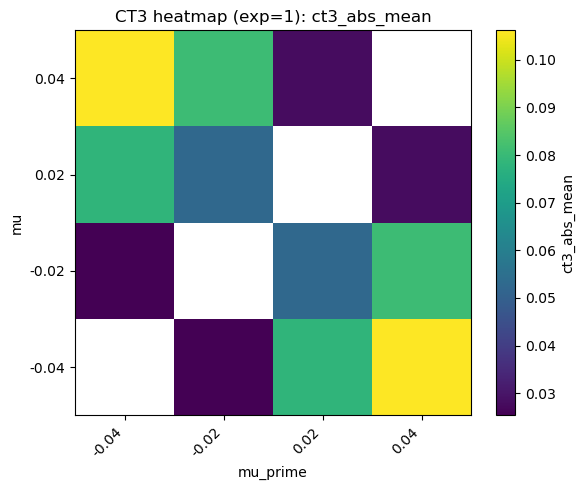

 experiment_id    mu  mu_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             1 -0.04     -0.02         0.025351        0.011085      0.025351     0.011085        3
             1 -0.04      0.02         0.078109        0.007759      0.078109     0.007759        3
             1 -0.04      0.04         0.106201        0.005660      0.106201     0.005660        3
             1 -0.02     -0.04        -0.025351        0.011085      0.025351     0.011085        3
             1 -0.02      0.02         0.052758        0.006022      0.052758     0.006022        3
             1 -0.02      0.04         0.080850        0.007219      0.080850     0.007219        3
             1  0.02     -0.04        -0.078109        0.007759      0.078109     0.007759        3
             1  0.02     -0.02        -0.052758        0.006022      0.052758     0.006022        3
             1  0.02      0.04         0.028092        0.002139      0.028092     0.002139        3


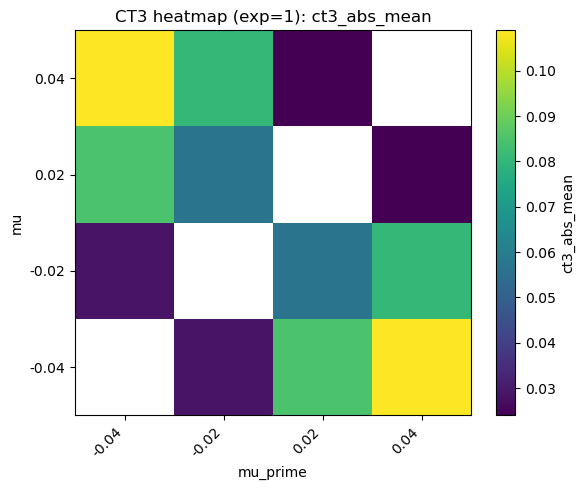

 experiment_id    mu  mu_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             1 -0.04     -0.02         0.028434        0.005274      0.028434     0.005274        3
             1 -0.04      0.02         0.084961        0.006527      0.084961     0.006527        3
             1 -0.04      0.04         0.108941        0.008222      0.108941     0.008222        3
             1 -0.02     -0.04        -0.028434        0.005274      0.028434     0.005274        3
             1 -0.02      0.02         0.056526        0.007411      0.056526     0.007411        3
             1 -0.02      0.04         0.080507        0.006022      0.080507     0.006022        3
             1  0.02     -0.04        -0.084961        0.006527      0.084961     0.006527        3
             1  0.02     -0.02        -0.056526        0.007411      0.056526     0.007411        3
             1  0.02      0.04         0.023981        0.004154      0.023981     0.004154        3


In [8]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/rw_drift_exp_1.csv", experiment_id=1, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/rw_drift_exp_1.csv", experiment_id=1, value_col="ct3_abs_mean")


Both models perform as expected with correct divergence.

# Experiment 2: AR(1)

Chronos


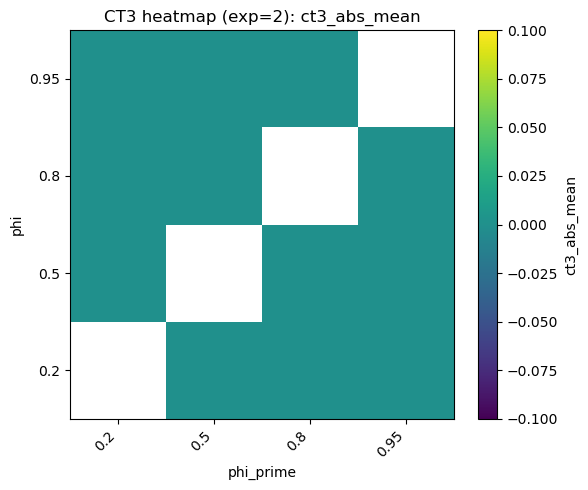

 experiment_id  phi  phi_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             2 0.20       0.50              0.0             0.0           0.0          0.0        3
             2 0.20       0.80              0.0             0.0           0.0          0.0        3
             2 0.20       0.95              0.0             0.0           0.0          0.0        3
             2 0.50       0.20              0.0             0.0           0.0          0.0        3
             2 0.50       0.80              0.0             0.0           0.0          0.0        3
             2 0.50       0.95              0.0             0.0           0.0          0.0        3
             2 0.80       0.20              0.0             0.0           0.0          0.0        3
             2 0.80       0.50              0.0             0.0           0.0          0.0        3
             2 0.80       0.95              0.0             0.0           0.0          0.0        3


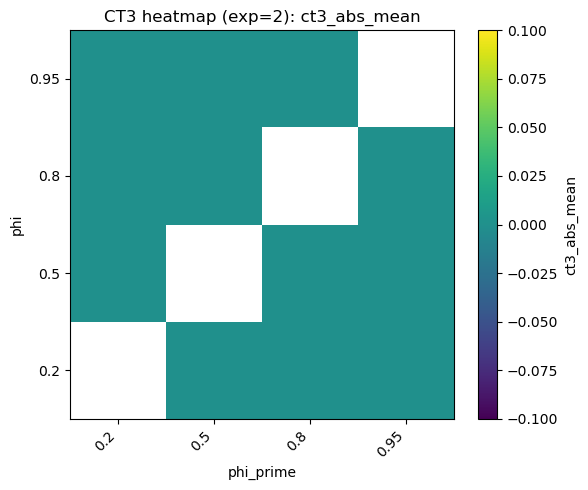

 experiment_id  phi  phi_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             2 0.20       0.50              0.0             0.0           0.0          0.0        3
             2 0.20       0.80              0.0             0.0           0.0          0.0        3
             2 0.20       0.95              0.0             0.0           0.0          0.0        3
             2 0.50       0.20              0.0             0.0           0.0          0.0        3
             2 0.50       0.80              0.0             0.0           0.0          0.0        3
             2 0.50       0.95              0.0             0.0           0.0          0.0        3
             2 0.80       0.20              0.0             0.0           0.0          0.0        3
             2 0.80       0.50              0.0             0.0           0.0          0.0        3
             2 0.80       0.95              0.0             0.0           0.0          0.0        3


In [9]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/ar1_exp_2.csv", experiment_id=2, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/ar1_exp_2.csv", experiment_id=2, value_col="ct3_abs_mean")

Both behave with incorrect invariance.

# Experiment 3: Harmonic Oscillator

Chronos


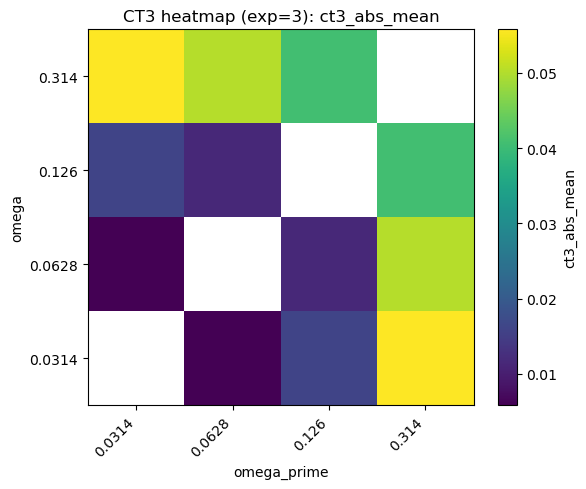

 experiment_id    omega  omega_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             3 0.031416     0.062832      0.005840     0.000600        3
             3 0.031416     0.125664      0.015990     0.000373        3
             3 0.031416     0.314159      0.055788     0.000815        3
             3 0.062832     0.031416      0.005840     0.000600        3
             3 0.062832     0.125664      0.011549     0.000278        3
             3 0.062832     0.314159      0.050220     0.000331        3
             3 0.125664     0.031416      0.015990     0.000373        3
             3 0.125664     0.062832      0.011549     0.000278        3
             3 0.125664     0.314159      0.040605     0.000483        3
             3 0.314159     0.031416      0.055788     0.000815        3
             3 0.314159     0.062832      0.050220     0.000331        3
             3 0.314159     0.125664      0.040605     0.000483        3
TimesFM


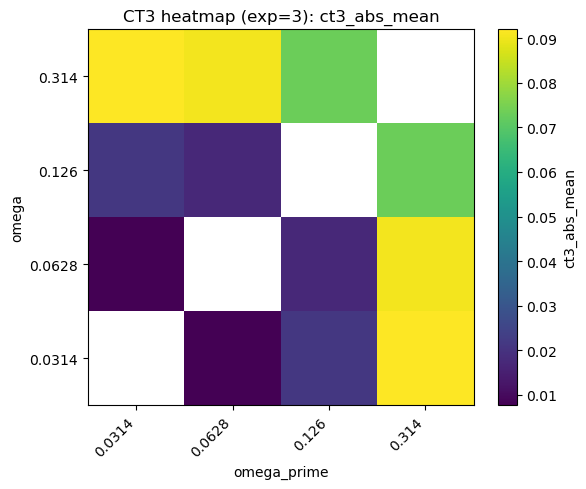

 experiment_id    omega  omega_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             3 0.031416     0.062832      0.007709     0.004306        3
             3 0.031416     0.125664      0.021229     0.002726        3
             3 0.031416     0.314159      0.091979     0.006073        3
             3 0.062832     0.031416      0.007709     0.004306        3
             3 0.062832     0.125664      0.017514     0.000655        3
             3 0.062832     0.314159      0.090341     0.001914        3
             3 0.125664     0.031416      0.021229     0.002726        3
             3 0.125664     0.062832      0.017514     0.000655        3
             3 0.125664     0.314159      0.073168     0.001828        3
             3 0.314159     0.031416      0.091979     0.006073        3
             3 0.314159     0.062832      0.090341     0.001914        3
             3 0.314159     0.125664      0.073168     0.001828        3


In [10]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/harmonic_exp_3.csv", experiment_id=3, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/harmonic_exp_3.csv", experiment_id=3, value_col="ct3_abs_mean")

Both show correct divergence.

# Experiment 4: AR(1) noise

Chronos


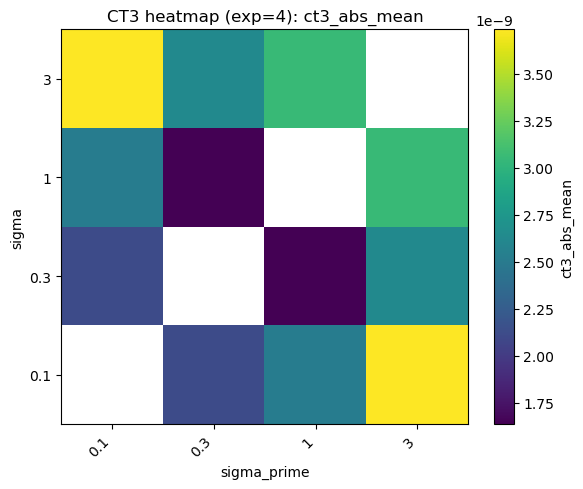

 experiment_id  sigma  sigma_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             4    0.1          0.3     1.616415e-10    3.025360e-09  2.112402e-09 1.580706e-09        3
             4    0.1          1.0     1.797518e-09    3.319051e-09  2.513459e-09 2.527150e-09        3
             4    0.1          3.0     2.310414e-09    4.271539e-09  3.735114e-09 2.307909e-09        3
             4    0.3          0.1    -1.616415e-10    3.025360e-09  2.112402e-09 1.580706e-09        3
             4    0.3          1.0     1.635876e-09    3.377381e-10  1.635876e-09 3.377381e-10        3
             4    0.3          3.0     2.148772e-09    4.012581e-09  2.631327e-09 3.555392e-09        3
             4    1.0          0.1    -1.797518e-09    3.319051e-09  2.513459e-09 2.527150e-09        3
             4    1.0          0.3    -1.635876e-09    3.377381e-10  1.635876e-09 3.377381e-10        3
             4    1.0          3.0     5.128964e-10    4.269214e

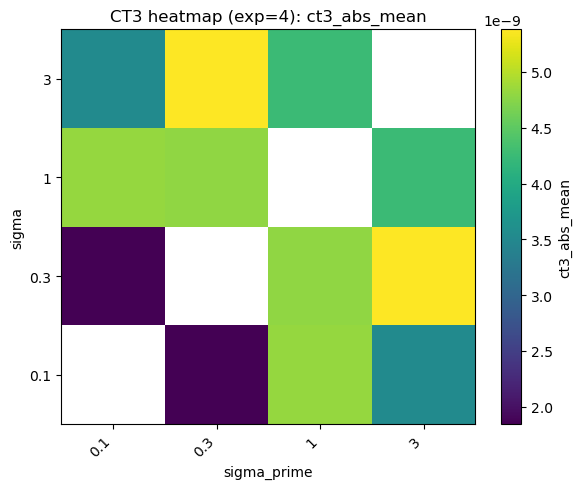

 experiment_id  sigma  sigma_prime  ct3_signed_mean  ct3_signed_std  ct3_abs_mean  ct3_abs_std  n_seeds
             4    0.1          0.3    -1.004658e-09    1.971724e-09  1.844318e-09 5.472102e-10        3
             4    0.1          1.0     4.134075e-10    6.995798e-09  4.819316e-09 3.789304e-09        3
             4    0.1          3.0     1.760696e-09    4.409753e-09  3.538117e-09 2.306207e-09        3
             4    0.3          0.1     1.004658e-09    1.971724e-09  1.844318e-09 5.472102e-10        3
             4    0.3          1.0     1.418065e-09    7.053324e-09  4.789925e-09 4.283770e-09        3
             4    0.3          3.0     2.765354e-09    6.120883e-09  5.382434e-09 2.340957e-09        3
             4    1.0          0.1    -4.134075e-10    6.995798e-09  4.819316e-09 3.789304e-09        3
             4    1.0          0.3    -1.418065e-09    7.053324e-09  4.789925e-09 4.283770e-09        3
             4    1.0          3.0     1.347289e-09    6.184883e

In [11]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/ar1_exp_4.csv", experiment_id=4, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/ar1_exp_4.csv", experiment_id=4, value_col="ct3_abs_mean")

Practically correct invariance due to miniscule scale of divergence.

# Experiment 5: Harmonic Oscillator amplitude

Chronos


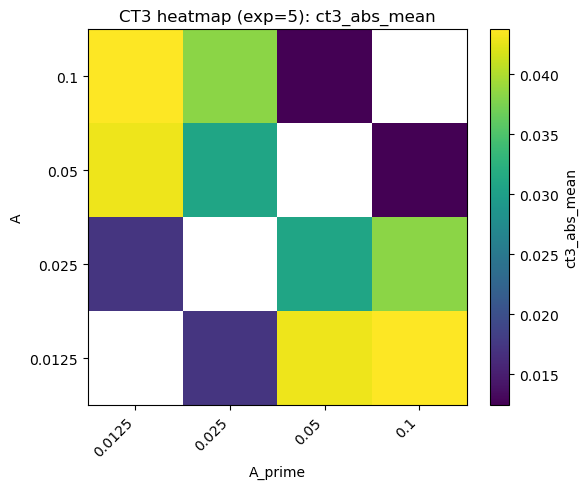

 experiment_id      A  A_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             5 0.0125   0.0250      0.017241     0.009659        3
             5 0.0125   0.0500      0.042893     0.003575        3
             5 0.0125   0.1000      0.043730     0.000332        3
             5 0.0250   0.0125      0.017241     0.009659        3
             5 0.0250   0.0500      0.030852     0.008148        3
             5 0.0250   0.1000      0.038303     0.008404        3
             5 0.0500   0.0125      0.042893     0.003575        3
             5 0.0500   0.0250      0.030852     0.008148        3
             5 0.0500   0.1000      0.012435     0.004373        3
             5 0.1000   0.0125      0.043730     0.000332        3
             5 0.1000   0.0250      0.038303     0.008404        3
             5 0.1000   0.0500      0.012435     0.004373        3
TimesFM


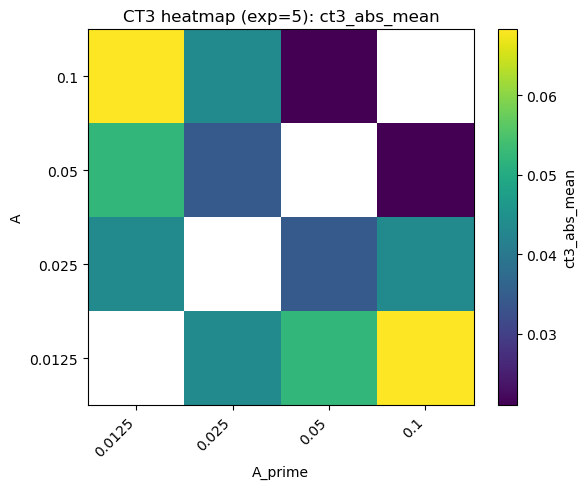

 experiment_id      A  A_prime  ct3_abs_mean  ct3_abs_std  n_seeds
             5 0.0125   0.0250      0.043682     0.026027        3
             5 0.0125   0.0500      0.052267     0.011572        3
             5 0.0125   0.1000      0.068269     0.006871        3
             5 0.0250   0.0125      0.043682     0.026027        3
             5 0.0250   0.0500      0.034335     0.013514        3
             5 0.0250   0.1000      0.043414     0.026335        3
             5 0.0500   0.0125      0.052267     0.011572        3
             5 0.0500   0.0250      0.034335     0.013514        3
             5 0.0500   0.1000      0.020999     0.004274        3
             5 0.1000   0.0125      0.068269     0.006871        3
             5 0.1000   0.0250      0.043414     0.026335        3
             5 0.1000   0.0500      0.020999     0.004274        3


In [12]:
print("Chronos")
plot_ct3_heatmap("artifacts/ct3/chronos/harmonic_exp_5.csv", experiment_id=5, value_col="ct3_abs_mean")
print("TimesFM")
plot_ct3_heatmap("artifacts/ct3/timesfm/harmonic_exp_5.csv", experiment_id=5, value_col="ct3_abs_mean")

Incorrect variance by both. TimesFM's wavelength estimate seems to be more sensitive to changes in amplitude.